# Parte 4 — Experimento B: BERTweet
### Workshop: Clasificación de Emociones en Twitter

**Modelo:** `vinai/bertweet-base`  
**Pre-entrenamiento:** 850M tweets en inglés  
**Tokenizador:** BPE entrenado sobre texto de Twitter

BERTweet tiene la misma arquitectura que BERT-base (12 capas, 768 dimensiones, ~110M parámetros), pero fue pre-entrenado desde cero sobre tweets.

> **Nota sobre `normalization=True`:** el tokenizador normaliza las URLs a `HTTPURL` y los @mentions a `@USER` antes de tokenizar, replicando el preprocesamiento usado durante el pre-entrenamiento.

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [4]:
import os, pathlib

# Ensure we run from the notebook's directory so relative %%run paths resolve
_nb_dir = pathlib.Path("/teamspace/studios/this_studio/deep-learning-mjbv-20261/Workshop 4 - NLP")
if not (_nb_dir / "tweeteval-part-2-pipeline.ipynb").exists():
    raise FileNotFoundError(f"Cannot find pipeline notebook in {_nb_dir}")
os.chdir(_nb_dir)

%run tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


## Configuración del experimento

In [5]:
MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO = "majonator/tweeteval-emotion-bertweet"
LR = 2e-5

### 📝 TODO 4.1 — Tokenizar el dataset con BERTweet

Importante: carga el tokenizador con `normalization=True`.

In [6]:
# TODO 4.1 ── Tokenizar con BERTweet
# ─────────────────────────────────────────────────────────────────────────────
tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet  = make_tokenized_dataset(tok_bertweet)
print(ds_bertweet)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


### 📝 TODO 4.2 — Cargar el modelo BERTweet

Mismo procedimiento que con DistilBERT pero con `MODEL_CHECKPOINT`. Imprime el número de parámetros y compáralo con DistilBERT.

In [7]:
# TODO 4.2 ── Cargar BERTweet para clasificación
# ─────────────────────────────────────────────────────────────────────────────
model_bertweet = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

In [8]:
total_params = sum(p.numel() for p in model_bertweet.parameters())
trainable_params = sum(p.numel() for p in model_bertweet.parameters() if p.requires_grad)
print(f"BERTweet  — Total parameters:     {total_params:,}")
print(f"BERTweet  — Trainable parameters: {trainable_params:,}")

BERTweet  — Total parameters:     134,903,044
BERTweet  — Trainable parameters: 134,903,044


Los parámetros de cada modelo se presenta en la siguiente tabla:

| Parámetro | DistilBERT | BERTweet |
|---|---|---|
| Total | 66,956,548 | 134,903,044 |
| Entrenables | 66,956,548 |  134,903,044 |

De la tabla anterior podemos ver que BERTweet tiene aproximadamente el doble de parámetros que DistilBERT, lo que le da mayor capacidad para aprender patrones complejos, pero a costa de más recursos computacionales. En cambio, DistilBERT es más eficiente y rápido, manteniendo un buen desempeño con menor tamaño.


### 📝 TODO 4.3 — Entrenar y evaluar BERTweet

Repite el mismo proceso del TODO 3.3 con el modelo y dataset de BERTweet.

**Pregunta:** ¿necesitarías cambiar el learning rate para BERTweet vs DistilBERT? ¿Por qué sí o por qué no?

In [9]:
# TODO 4.3 ── Entrenamiento de BERTweet
# ─────────────────────────────────────────────────────────────────────────────
trainer_bertweet = make_trainer(
    model = model_bertweet,
    tokenizer = tok_bertweet,
    tokenized_ds = ds_bertweet,
    output_dir = "./checkpoints/bertweet",
    lr = LR,
)
trainer_bertweet.train()

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.860082,0.738039,0.695086,0.767380
2,0.614746,0.667101,0.719028,0.783422
3,0.428337,0.516064,0.786866,0.834225
4,0.354197,0.531086,0.773792,0.823529
5,0.274989,0.523600,0.789208,0.834225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=510, training_loss=0.5896212919085634, metrics={'train_runtime': 75.1303, 'train_samples_per_second': 216.757, 'train_steps_per_second': 6.788, 'total_flos': 327653147532672.0, 'train_loss': 0.5896212919085634, 'epoch': 5.0})

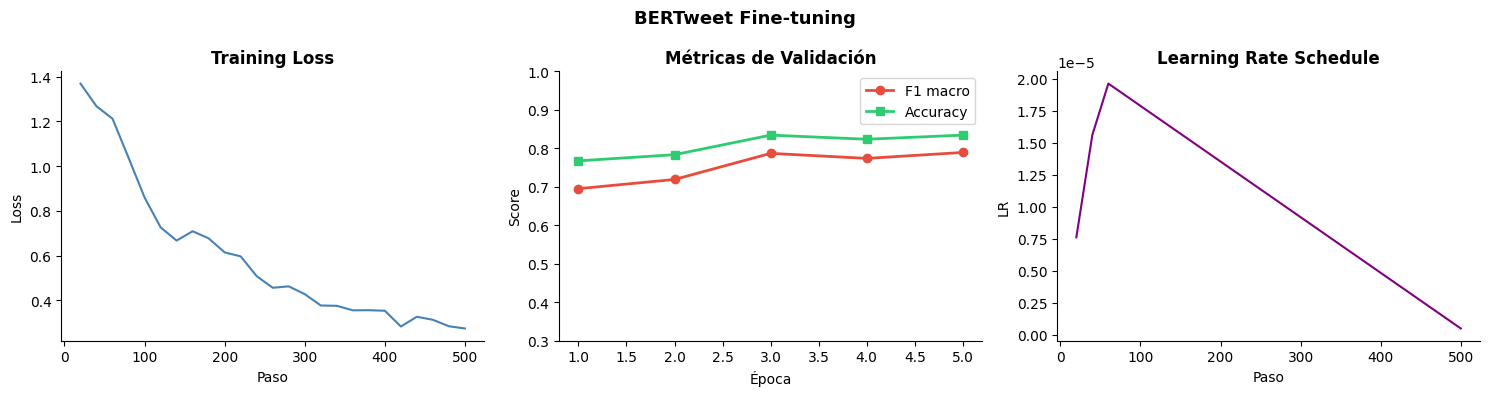

In [10]:
plot_training_curves(trainer_bertweet, title="BERTweet Fine-tuning")

De las gráficas anteriores, podemos ver que en BERTweet, la función de pérdida también desciende de forma constante a lo largo del entrenamiento, pasando de cerca de 1.4 al inicio a alrededor de 0.3 al final, lo que indica un ajuste progresivo a los datos. Además, el F1 macro mejora de aproximadamente 0.69 a 0.79, con su mayor ganancia hasta la época 3 y luego una estabilización con pequeñas variaciones, lo que sugiere una convergencia alrededor de F1≈0.79, un desempeño ligeramente mejor que DistilBERT. Finalmente, la gráfica del learning rate schedule muestra el mismo patrón de calentamiento inicial seguido de una reducción gradual hasta casi 0, favoreciendo un entrenamiento estable y una convergencia adecuada.


**¿necesitarías cambiar el learning rate para BERTweet vs DistilBERT? ¿Por qué sí o por qué no?**
No, ambos modelos muestran curvas de pérdida estables, mejora sostenida en validación y un learning rate schedule muy similar, por lo que no hay evidencia clara de que BERTweet ni DistilBERT requieran un learning rate distinto.


  Test — BERTweet
              precision    recall  f1-score   support

       anger     0.8779    0.8889    0.8833       558
         joy     0.8711    0.8492    0.8600       358
    optimism     0.7383    0.6423    0.6870       123
     sadness     0.8025    0.8403    0.8210       382

    accuracy                         0.8445      1421
   macro avg     0.8224    0.8052    0.8128      1421
weighted avg     0.8438    0.8445    0.8437      1421



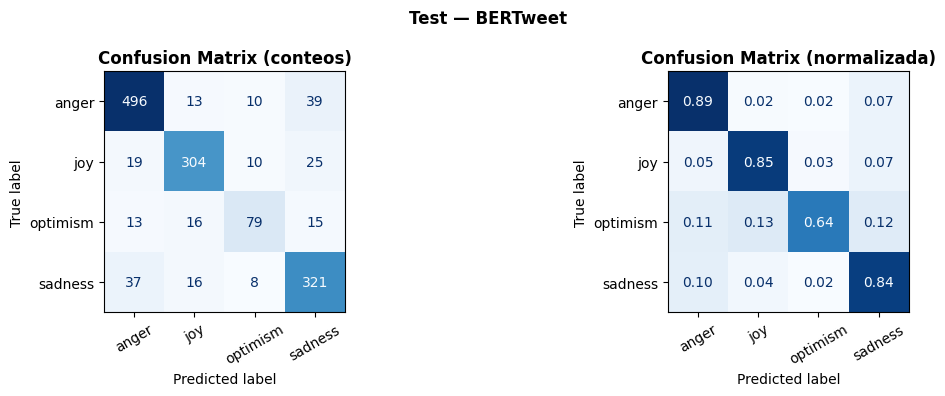

In [11]:
metrics_bertweet = full_evaluation(trainer_bertweet, ds_bertweet["test"],
                                   model_name="BERTweet")

El modelo BERTweet muestra un desempeño general sólido, con métricas altas en anger, joy y sadness, donde la mayoría de las predicciones se concentran correctamente en la diagonal de la matriz de confusión. La clase optimism sigue siendo la más desafiante, aunque presenta una mejora notable frente a DistilBERT, con menor dispersión de errores hacia las demás clases. 

En comparación con DistilBERT, BERTweet presenta un rendimiento superior, especialmente en la clase optimism, reduciendo errores y mejorando la separación entre clases. Esto puede explicarse por la forma en que fue entrenado su tokenizador, adaptado al lenguaje de redes sociales, y por su mayor capacidad representacional, dado que tiene casi el doble de parámetros.

## Push to Hub

In [12]:
# Requiere: huggingface-cli login  (o haber cargado el token con python-dotenv)
trainer_bertweet.model.push_to_hub(
    HF_REPO,
    commit_message="BERTweet fine-tuning — TweetEval emotion",
)
tok_bertweet.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Modelo publicado en: https://huggingface.co/majonator/tweeteval-emotion-bertweet
